In [2]:
import json, os, shutil

BASE_DIR = "/kaggle/input/datasets/sharansmenon/aquarium-dataset/Aquarium Combined"
OUT_DIR  = "/kaggle/working/aquarium-yolo"

splits = ["train", "valid", "test"]
class_names = []

for split in splits:
    src_dir = os.path.join(BASE_DIR, split)
    img_out = os.path.join(OUT_DIR, split, "images")
    lbl_out = os.path.join(OUT_DIR, split, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    with open(os.path.join(src_dir, "_annotations.coco.json")) as f:
        coco = json.load(f)

    if split == "train":
        categories = sorted(coco["categories"], key=lambda c: c["id"])
        categories = [c for c in categories if c["name"].lower() not in ("background", "creatures")]
        class_names = [c["name"] for c in categories]
        cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}

    images = {img["id"]: img for img in coco["images"]}

    anns_by_image = {}
    for ann in coco["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    for img_id, img_info in images.items():
        file_name = img_info["file_name"]
        w, h = img_info["width"], img_info["height"]

        shutil.copy(os.path.join(src_dir, file_name), os.path.join(img_out, file_name))

        label_path = os.path.join(lbl_out, os.path.splitext(file_name)[0] + ".txt")
        lines = []
        for ann in anns_by_image.get(img_id, []):
            cat_id = ann["category_id"]
            if cat_id not in cat_id_to_idx:
                continue
            cls_idx = cat_id_to_idx[cat_id]
            x, y, bw, bh = ann["bbox"]
            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            bw_norm = bw / w
            bh_norm = bh / h
            lines.append(f"{cls_idx} {x_center:.6f} {y_center:.6f} {bw_norm:.6f} {bh_norm:.6f}")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print(f"{split}: {len(images)} images converted")

print("\nClasses:", class_names)

train: 448 images converted
valid: 127 images converted
test: 63 images converted

Classes: ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']


In [3]:
yaml_content = f"""train: {OUT_DIR}/train/images
val: {OUT_DIR}/valid/images
test: {OUT_DIR}/test/images

nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(OUT_DIR, "data.yaml"), "w") as f:
    f.write(yaml_content)

print(yaml_content)

train: /kaggle/working/aquarium-yolo/train/images
val: /kaggle/working/aquarium-yolo/valid/images
test: /kaggle/working/aquarium-yolo/test/images

nc: 7
names: ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']



In [4]:
!pip install ultralytics --quiet

from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=f"{OUT_DIR}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/aquarium-yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [5]:
metrics = model.val()
print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1666.2±670.7 MB/s, size: 109.4 KB)
val: Scanning /kaggle/working/aquarium-yolo/valid/labels.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 44.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.6it/s 3.1s0.2s
                   all        127        909      0.741      0.716      0.742       0.45
                  fish         63        459      0.755      0.749      0.787      0.446
             jellyfish          9        155      0.776      0.916      0.922      0.528
               penguin         17        104      0.616      0.721      0.694      0.324
                puffin         15         74      0.618      0.502      0.521      0.275
                 shark         28

In [6]:
results = model.predict(source=f"{OUT_DIR}/test/images", save=True, conf=0.25)


image 1/63 /kaggle/working/aquarium-yolo/test/images/IMG_2289_jpeg_jpg.rf.fe2a7a149e7b11f2313f5a7b30386e85.jpg: 640x480 1 puffin, 44.8ms
image 2/63 /kaggle/working/aquarium-yolo/test/images/IMG_2301_jpeg_jpg.rf.2c19ae5efbd1f8611b5578125f001695.jpg: 640x480 27 penguins, 6.3ms
image 3/63 /kaggle/working/aquarium-yolo/test/images/IMG_2319_jpeg_jpg.rf.6e20bf97d17b74a8948aa48776c40454.jpg: 640x480 10 penguins, 7.2ms
image 4/63 /kaggle/working/aquarium-yolo/test/images/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg: 640x480 1 penguin, 6.3ms
image 5/63 /kaggle/working/aquarium-yolo/test/images/IMG_2354_jpeg_jpg.rf.396e872c7fb0a95e911806986995ee7a.jpg: 640x480 5 penguins, 6.3ms
image 6/63 /kaggle/working/aquarium-yolo/test/images/IMG_2371_jpeg_jpg.rf.54505f60b6706da151c164188c305849.jpg: 640x480 3 fishs, 6.7ms
image 7/63 /kaggle/working/aquarium-yolo/test/images/IMG_2379_jpeg_jpg.rf.7dc3160c937072d26d4624c6c48e904d.jpg: 640x480 2 fishs, 6.1ms
image 8/63 /kaggle/working/aquarium-yol

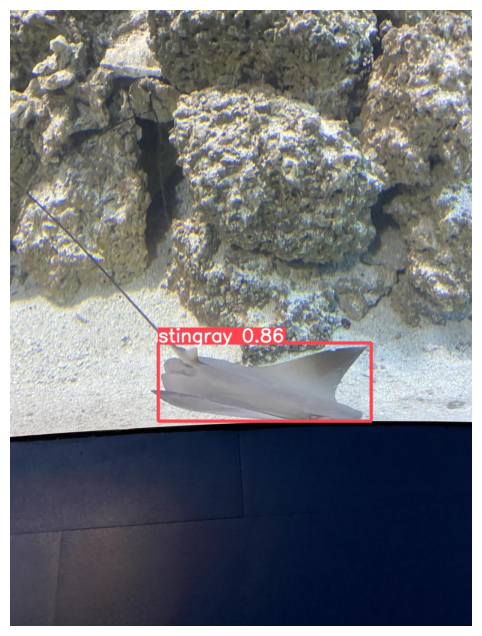

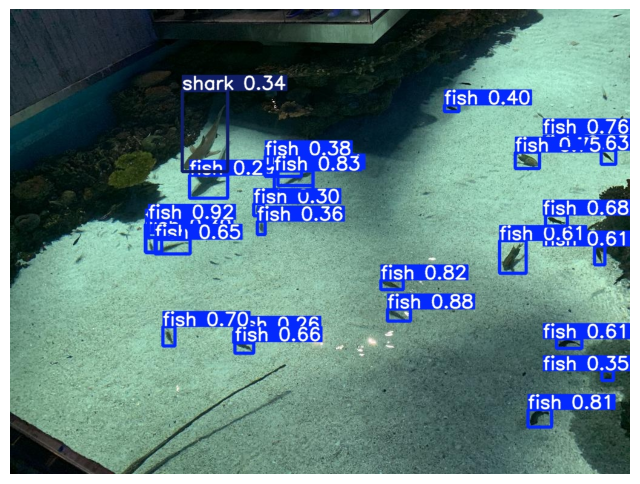

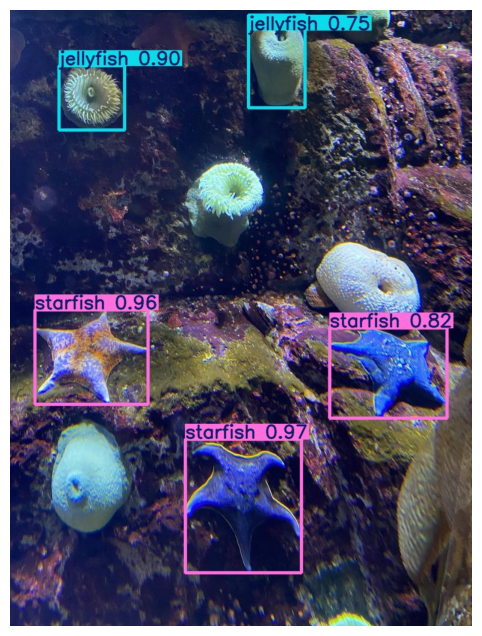

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

pred_dir = sorted(glob.glob("/kaggle/working/runs/detect/predict*"))[-1]
for img_path in glob.glob(f"{pred_dir}/*.jpg")[:3]:
    img = mpimg.imread(img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()